# Carbon Footprint Prediction Using Machine Learning

### 1. Import Required Libraries

In [16]:
# Import libraries for data handling and ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

# ML tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import cross_val_score

### 2. Load Dataset

In [17]:
# Load dataset
df = pd.read_csv("personal_carbon_footprint_behavior.csv")

# Display first 5 rows
df.head()

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium


###  3. Basic Data Understanding

In [18]:
# Show dataset info
df.info()

# Check for missing values
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1400 non-null   int64  
 1   day_type             1400 non-null   str    
 2   transport_mode       1400 non-null   str    
 3   distance_km          1400 non-null   float64
 4   electricity_kwh      1400 non-null   float64
 5   renewable_usage_pct  1400 non-null   int64  
 6   food_type            1400 non-null   str    
 7   screen_time_hours    1400 non-null   float64
 8   waste_generated_kg   1400 non-null   float64
 9   eco_actions          1400 non-null   int64  
 10  carbon_footprint_kg  1400 non-null   float64
 11  carbon_impact_level  1400 non-null   str    
dtypes: float64(5), int64(3), str(4)
memory usage: 159.1 KB
user_id                0
day_type               0
transport_mode         0
distance_km            0
electricity_kwh        0
renewable_usage_pct

### 4: Remove Unnecessary & Leakage Columns

In [19]:
# Remove unnecessary and leakage columns
df = df.drop(["user_id", "carbon_footprint_kg"], axis=1)

# Check updated data
df.head()

,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_impact_level
0,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,High
1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,Medium
2,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,Medium
3,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,High
4,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,Medium


### 5: Convert Categorical Data → Numerical

In [20]:
# Convert categorical (text) columns into numerical using one-hot encoding
df = pd.get_dummies(df)

# Check updated dataset
df.head()

,distance_km,electricity_kwh,renewable_usage_pct,screen_time_hours,waste_generated_kg,eco_actions,day_type_Weekday,day_type_Weekend,transport_mode_Bike,transport_mode_Bus,transport_mode_Car,transport_mode_EV,transport_mode_Walk,food_type_Mixed,food_type_Non-Veg,food_type_Veg,carbon_impact_level_High,carbon_impact_level_Low,carbon_impact_level_Medium
0,1.55,6.12,0,2.4,0.70,1,False,True,False,False,False,True,False,False,True,False,True,False,False
1,10.04,4.50,0,4.1,0.54,1,False,True,False,False,False,False,True,True,False,False,False,False,True
2,15.27,2.81,0,4.0,0.51,1,True,False,False,False,False,False,True,True,False,False,False,False,True
3,0.50,10.16,0,6.3,0.73,0,False,True,False,False,False,False,True,True,False,False,True,False,False
4,3.60,5.02,50,5.1,0.64,0,False,True,False,False,False,False,True,True,False,False,False,False,True


### 6: Define Features (X) and Target (y)

In [21]:
# Define target variable (y)
y = df["carbon_impact_level_High"]

# Define input features (X)
X = df.drop(
    ["carbon_impact_level_High", "carbon_impact_level_Low", "carbon_impact_level_Medium"],
    axis=1
)

# Check shapes
print(X.shape)
print(y.shape)

(1400, 16)
(1400,)


### 7: Split Data (Train & Test)

In [22]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # ensures same result every time
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1120, 16)
X_test: (280, 16)
y_train: (1120,)
y_test: (280,)


### 8: Train the Model (Random Forest)

In [23]:
# Create model
model = RandomForestClassifier()

# Train model using training data
model.fit(X_train, y_train)
print("Model training completed ✅")

Model training completed ✅


### 9: Prediction + Accuracy

In [24]:
# Predict using test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9357142857142857


### 10: Confusion Matrix + Classification Report

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[234   0]
 [ 18  28]]

Classification Report:
               precision    recall  f1-score   support

       False       0.93      1.00      0.96       234
        True       1.00      0.61      0.76        46

    accuracy                           0.94       280
   macro avg       0.96      0.80      0.86       280
weighted avg       0.94      0.94      0.93       280



### 11: Cross Validation

In [26]:
cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.91785714 0.92857143 0.95357143 0.96071429 0.96071429]
Average CV Score: 0.9442857142857143


### 12: Feature Importance


In [27]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Top Features:\n", feature_importance.head(10))

Top Features:
 electricity_kwh        0.281494
renewable_usage_pct    0.182026
food_type_Non-Veg      0.103468
waste_generated_kg     0.092432
distance_km            0.092366
screen_time_hours      0.063603
eco_actions            0.041330
food_type_Veg          0.035917
transport_mode_Car     0.032930
food_type_Mixed        0.019433
dtype: float64


### 13: Visualization (Graph)

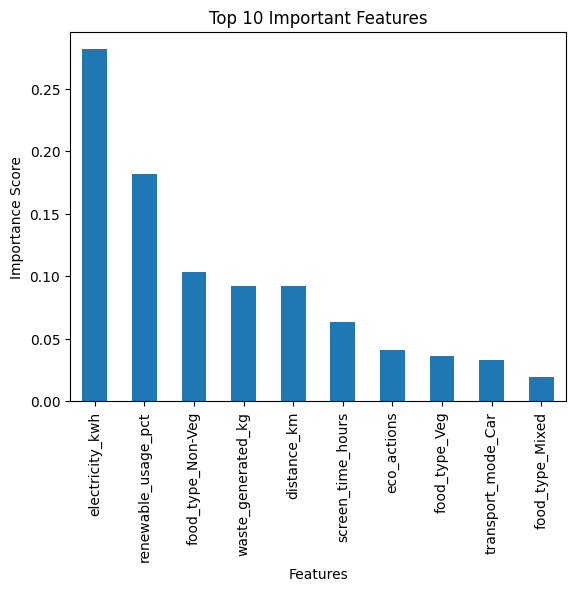

In [ ]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

In [30]:
# Reload original dataset (IMPORTANT FIX)
df = pd.read_csv("personal_carbon_footprint_behavior.csv")

# Convert categorical to numerical again
df = pd.get_dummies(df)

### 14: Regression Model

In [33]:
# Step 14: Regression Model (Predict Carbon Footprint Value)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define target (numeric)
y_reg = df["carbon_footprint_kg"]

# Define features
X_reg = df.drop("carbon_footprint_kg", axis=1)

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train model
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = reg_model.predict(X_test_r)

### 15: MAE, MSE, RMSE, R²

In [ ]:
# 15: Regression Metrics

# MAE
mae = mean_absolute_error(y_test_r, y_pred_r)

# MSE
mse = mean_squared_error(y_test_r, y_pred_r)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test_r, y_pred_r)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.41607759125919425
MSE: 0.30973525443360383
RMSE: 0.5565386369638714
R2 Score: 0.9589464380748702


In [36]:
# Compare Actual vs Predicted values
comparison = pd.DataFrame({
    "Actual": y_test_r,
    "Predicted": y_pred_r
})

print(comparison.head())

     Actual  Predicted
665    5.56   5.849482
624   10.30   9.518489
115    9.03   9.000362
478    3.80   4.487697
233    4.85   5.468460
